# 02 — EDA Ratings

Owned by **Data Engineer** (+ Pipeline support).

Goals: user/movie counts, rating distribution, sparsity, memory notes.

In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
ratings = pd.read_csv(
    ROOT / "data" / "raw" / "ratings.csv",
    dtype={
        "userId": "int32",
        "movieId": "int32",
        "rating": "float32",
        "timestamp": "int64",
    },
)
ratings.head()

,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510


In [4]:
n_users = ratings["userId"].nunique()
n_movies = ratings["movieId"].nunique()
n_ratings = len(ratings)
sparsity = 1 - n_ratings / (n_users * n_movies)
n_users, n_movies, n_ratings, sparsity

(162541, 59047, 25000095, 0.9973951609474271)

In [5]:
ratings["rating"].mean()

np.float32(3.5338545)

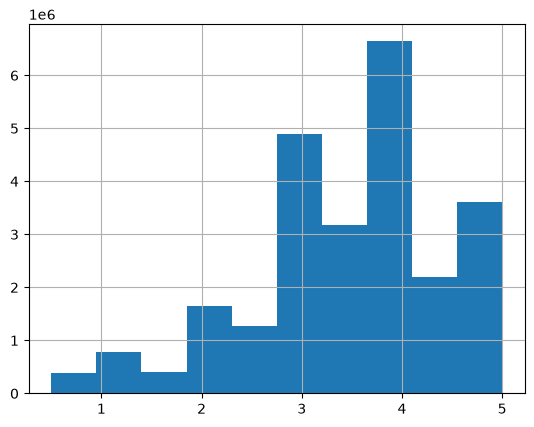

In [6]:
ratings["rating"].hist()
plt.show()

<Axes: >

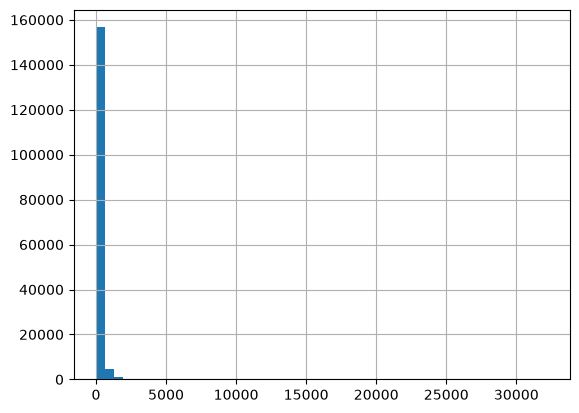

In [7]:
#User activity distribution
user_counts = ratings.groupby("userId").size()
user_counts.describe()
user_counts.hist(bins=50)

In [8]:
user_counts.quantile([0.1,0.5,0.75,0.9,0.95,0.99])
  # có đến 50% users đánh giá <=71 phim

0.10      24.0
0.50      71.0
0.75     162.0
0.90     353.0
0.95     554.0
0.99    1228.0
dtype: float64

<Axes: >

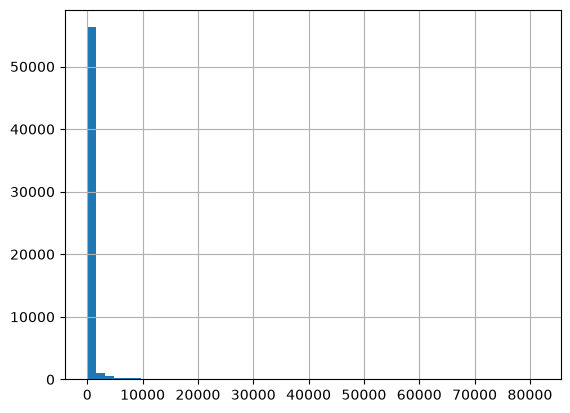

In [9]:
#Movie popularity distribution
movie_counts = ratings.groupby("movieId").size()
movie_counts.hist(bins=50)

In [10]:
movie_counts.quantile([0.5,0.60, 0.75,0.9,0.95,0.99])
    #Có đến 50% số phim có lượt ratings <=6

0.50       6.00
0.60      10.00
0.75      36.00
0.90     413.00
0.95    1503.40
0.99    9941.62
dtype: float64

In [11]:
ratings.to_parquet("ratings.parquet", index=False)
pd.read_parquet("ratings.parquet")

,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510
...,...,...,...,...
25000090,162541,50872,4.5,1240953372
25000091,162541,55768,2.5,1240951998
25000092,162541,56176,2.0,1240950697
25000093,162541,58559,4.0,1240953434
